# new formulation for propagating error as in Genereux (1998), in the U-space

Interannual dataframe successfully compiled. Total samples: 1144
Available columns: ['Sample ID', 'Site', 'Date', 'Time', 'Type', 'Type2', 'Index-notes', 'ICP-notes', 'Fe_mg_L', 'Mn_mg_L', 'Cu_mg_L', 'Zn_mg_L', 'Si_mg_L', 'K_mg_L', 'P_mg_L', 'Mg_mg_L', 'Na_mg_L', 'Al_mg_L', 'Ca_mg_L', 'Fl_mg_L', 'Cl_mg_L', 'NO2_mg_L', 'Br_mg_L', 'NO3_mg_L', 'PO4_mg_L', 'SO4_mg_L', 'IC-notes', 'NRS_LWIA_notes', 'dD', 'd18O', 'iso-notes', 'TOC run date', 'TOC mg_L', 'TOC notes', 'Type3', 'S. No.', 'Transect', 'Depth', 'Pit', 'NO3_N_mg_L', 'SO4_S_mg_L', 'PO4_P_mg_L', 'Time Zone', 'Freezer bag #', 'UVM ICPOES prep date', 'ICPOES-notes-MED', 'Ba_mg_L', 'S_mg_L', 'Sr_mg_L', 'IC-notes_MED', 'Isotope/ICP pick list #', 'Acidified for ICPOES? (Y or N)', 'MED Index Notes', 'NRS Lab Comments', 'Datetime']
Saved plot to: /home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Hungerford_B._Hungerford_Mar._thermal_Mar_21–26.jpg


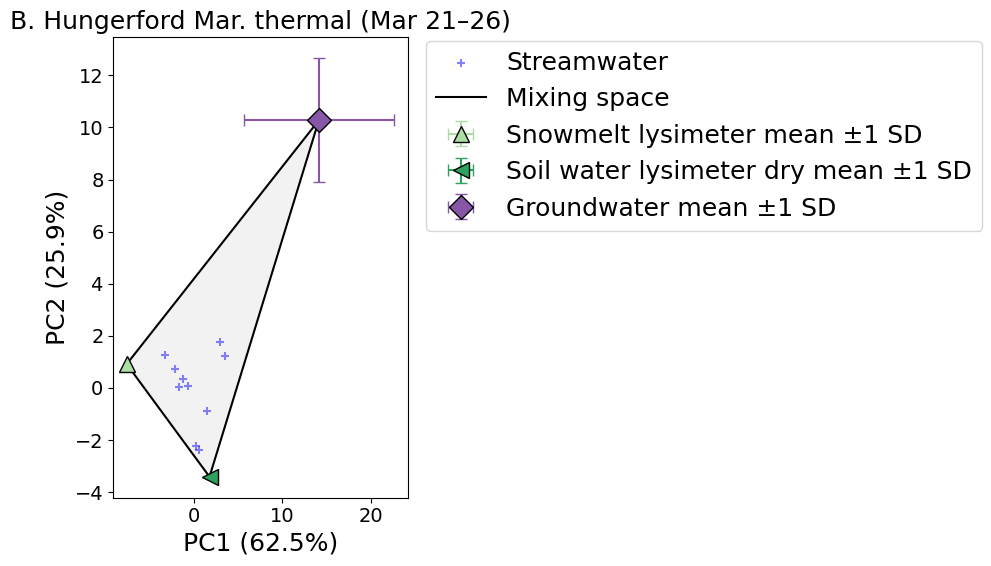

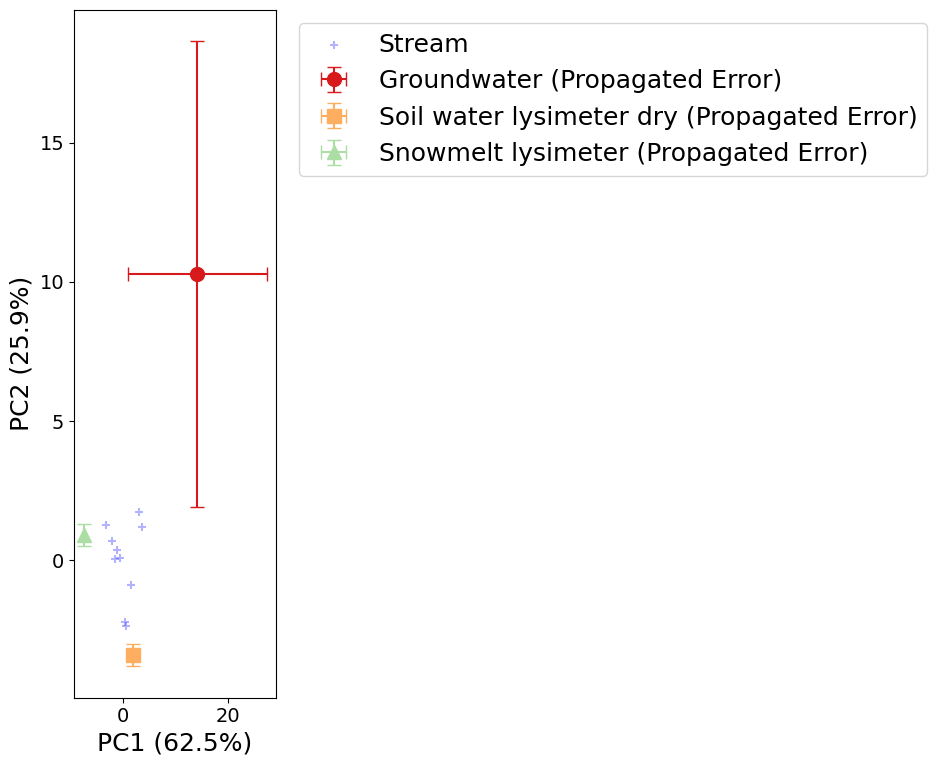

                       Type    PC1_err   PC2_err
0               Groundwater  13.244738  8.362897
1  Soil water lysimeter dry   0.082491  0.395149
2        Snowmelt lysimeter   0.082491  0.395149


In [12]:
import sys
sys.path.append("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/")  

import importlib
import pandas as pd
import EMMA.event_pca_error as ep
importlib.reload(ep)

import sys
sys.path.append("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/")  

import importlib
import pandas as pd
import EMMA.event_emma as em # contains endmember-average EMMA function
importlib.reload(em)

# Load the full RI23 dataset
df_23 = pd.read_csv("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/GrabSample_data/RI23-IC-ICP-isotope-toc-joined.csv")

# Load earlier and later datasets to allow for multiyear groundwater means if needed
df_20 = pd.read_csv("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/GrabSample_data/RI18-20-IC-ICP.csv")
df_22 = pd.read_csv("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/GrabSample_data/RI22-IC-ICP-isotope.csv")
df_24 = pd.read_csv("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/GrabSample_data/RI24-IC-ICP-isotope-joined.csv")
df_25 = pd.read_csv("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/GrabSample_data/RI25-IC-ICP-isotope-joined.csv")

# Combine yearly datasets into single dataframe
# 1. Standardize core column names before combining (in case they vary)
# Ensures "Sample ID" and "Sample Type" line up cleanly across all years
for df_temp in [df_20, df_22, df_23, df_24, df_25]:
    # Fix any variations of 'Sample ID' with or without underscores
    if 'Sample_ID' in df_temp.columns:
        df_temp.rename(columns={'Sample_ID': 'Sample ID'}, inplace=True)
    if 'Sample.Type' in df_temp.columns:
        df_temp.rename(columns={'Sample.Type': 'Type'}, inplace=True)
    elif 'Sample_Type' in df_temp.columns:
        df_temp.rename(columns={'Sample_Type': 'Type'}, inplace=True)

# 2. Combine all dataframes vertically
# axis=0 stacks them on top of each other, sort=False preserves the column order of df_23
df = pd.concat([df_23, df_20, df_22, df_24, df_25], axis=0, ignore_index=True, sort=False)

# 3. Clean up the Datetime formatting for the whole master dataframe
# (Ensures the stream and endmember slicing logic works inside the EMMA module)
df['Datetime'] = df['Date'].astype(str) + ' ' + df['Time'].astype(str)
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%m/%d/%Y %H:%M", errors="coerce")
df = df[df['Datetime'].notna()]

print(f"Interannual dataframe successfully compiled. Total samples: {df.shape[0]}")
print(f"Available columns: {list(df.columns)}")

# Analytical uncertainty for tracers

analytical_precision_ri23 = {
    'Ca_mg_L': 0.05,  # mg/L
    'Si_mg_L': 0.05,  # mg/L
    'Mg_mg_L': 0.05,  # mg/L
    'K_mg_L': 0.05,  # mg/L
    'Na_mg_L': 0.05,  # mg/L
    'Cl_mg_L': 0.10,  # mg/L
    'd18O': 0.1,      # permille
    'dD': 0.1    # permille
}

##########################
# Hungerford RI23 events #
##########################

# A. February ROS
# B. March thermal
# C. Final spring melt

# Hungerford March thermal event
# Potential endmembers: 
    # RI23-5008 Groundwater (Mark's well) 03/16/2023
    # RI20-HB-DGW-Mark-1 Mark's well 06/23/2020
    # RI22-0858 03/17/2022 Hungerford groundwater from Meghan (assume Mark's well)
    # RI22-0864 07/27/2022 Hungerford groundwater from Meghan (assume Mark's well)
    # RI23-1035 Baseflow 03/31/2023
    # RI23-1001 # Baseflow 02/09/2023 (labeled GW)
    # RI23-5007 Soil water lysimeter dry 03/16/2023
    # RI23-1061 Snowmelt lysimeter 03/28/2023

ep.plot_event_pca_with_avgEM(
    data=df,
    site="Hungerford",
    start_date="2023-03-21",
    end_date="2023-03-26",
    endmember_ids=["RI23-1001", # Baseflow 02/09/2023 (labeled GW)
                   "RI23-5008", # Mark's well 2023
                   "RI20-HB-DGW-Mark-1" # Mark's well 2020
                   "RI22-0858", # Mark's well 03/17/2022
                   "RI22-0864",
                   #"RI23-1035", Baseflow 03/31/2023 removed for now
                   "RI23-5007", # SWLD
                   "RI23-1061"],  
    title="B. Hungerford Mar. thermal (Mar 21–26)"
)

stats_em, pca_model, scaler_model = ep.plot_event_pca_with_error(
    data=df,
    site="Hungerford",
    start_date="2023-03-21",
    end_date="2023-03-26",
        endmember_ids=["RI23-1001", # Baseflow 02/09/2023 (labeled GW)
                   "RI23-5008", # Mark's well 2023
                   "RI20-HB-DGW-Mark-1" # Mark's well 2020
                   "RI22-0858", # Mark's well 03/17/2022
                   "RI22-0864", # Mark's well 07/27/2022
                   #"RI23-1035", Baseflow 03/31/2023 removed for now
                   "RI23-5007", # SWLD
                   "RI23-1061"],  
    analytical_dict=analytical_precision_ri23, # Pass your dictionary here
    title="B. Hungerford Mar. thermal (Mar 21–26)"
)

# Now 'stats_em' contains your PC1_err and PC2_err for each endmember!
print(stats_em[['Type', 'PC1_err', 'PC2_err']])

Interannual dataframe successfully compiled. Total samples: 1144
Available columns: ['Sample ID', 'Site', 'Date', 'Time', 'Type', 'Type2', 'Index-notes', 'ICP-notes', 'Fe_mg_L', 'Mn_mg_L', 'Cu_mg_L', 'Zn_mg_L', 'Si_mg_L', 'K_mg_L', 'P_mg_L', 'Mg_mg_L', 'Na_mg_L', 'Al_mg_L', 'Ca_mg_L', 'Fl_mg_L', 'Cl_mg_L', 'NO2_mg_L', 'Br_mg_L', 'NO3_mg_L', 'PO4_mg_L', 'SO4_mg_L', 'IC-notes', 'NRS_LWIA_notes', 'dD', 'd18O', 'iso-notes', 'TOC run date', 'TOC mg_L', 'TOC notes', 'Type3', 'S. No.', 'Transect', 'Depth', 'Pit', 'NO3_N_mg_L', 'SO4_S_mg_L', 'PO4_P_mg_L', 'Time Zone', 'Freezer bag #', 'UVM ICPOES prep date', 'ICPOES-notes-MED', 'Ba_mg_L', 'S_mg_L', 'Sr_mg_L', 'IC-notes_MED', 'Isotope/ICP pick list #', 'Acidified for ICPOES? (Y or N)', 'MED Index Notes', 'NRS Lab Comments', 'Datetime']
Saved plot to: /home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Hungerford_C._Hungerford_Feb._ROS_Feb_08-12.jpg


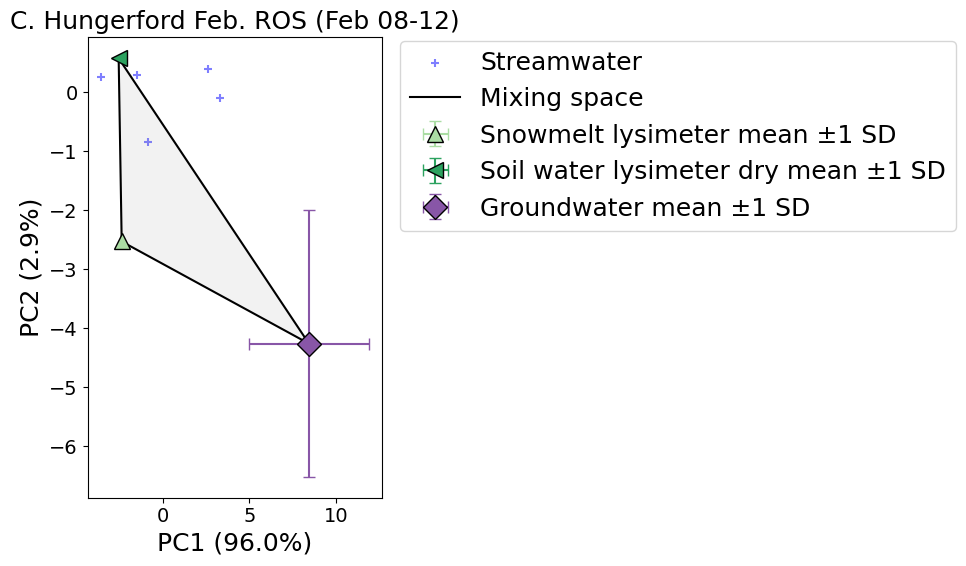

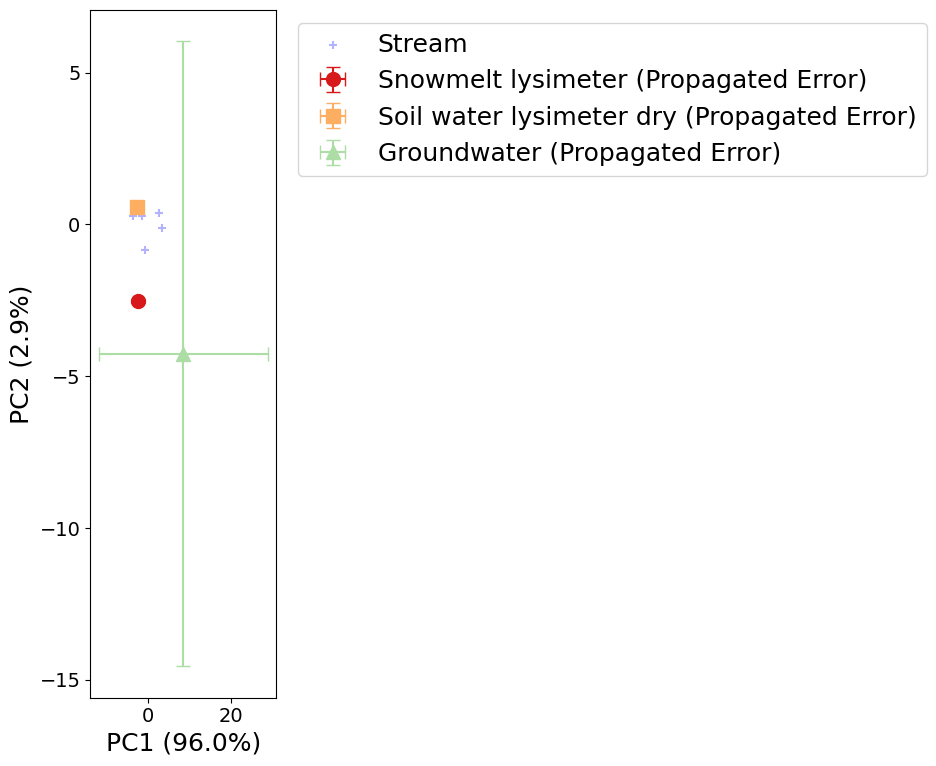

                       Type    PC1_err    PC2_err
0        Snowmelt lysimeter   0.052838   0.062736
1  Soil water lysimeter dry   0.052838   0.062736
2               Groundwater  20.323052  10.295021


In [14]:
import sys
sys.path.append("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/")  

import importlib
import pandas as pd
import EMMA.event_pca_error as ep
importlib.reload(ep)

import sys
sys.path.append("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/")  

import importlib
import pandas as pd
import EMMA.event_emma as em # contains endmember-average EMMA function
importlib.reload(em)

# Load the full RI23 dataset
df_23 = pd.read_csv("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/GrabSample_data/RI23-IC-ICP-isotope-toc-joined.csv")

# Load earlier and later datasets to allow for multiyear groundwater means if needed
df_20 = pd.read_csv("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/GrabSample_data/RI18-20-IC-ICP.csv")
df_22 = pd.read_csv("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/GrabSample_data/RI22-IC-ICP-isotope.csv")
df_24 = pd.read_csv("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/GrabSample_data/RI24-IC-ICP-isotope-joined.csv")
df_25 = pd.read_csv("/home/millieginty/OneDrive/git-repos/LCBP-interannual-EMMAs/Data/GrabSample_data/RI25-IC-ICP-isotope-joined.csv")

# Combine yearly datasets into single dataframe
# 1. Standardize core column names before combining (in case they vary)
# Ensures "Sample ID" and "Sample Type" line up cleanly across all years
for df_temp in [df_20, df_22, df_23, df_24, df_25]:
    # Fix any variations of 'Sample ID' with or without underscores
    if 'Sample_ID' in df_temp.columns:
        df_temp.rename(columns={'Sample_ID': 'Sample ID'}, inplace=True)
    if 'Sample.Type' in df_temp.columns:
        df_temp.rename(columns={'Sample.Type': 'Type'}, inplace=True)
    elif 'Sample_Type' in df_temp.columns:
        df_temp.rename(columns={'Sample_Type': 'Type'}, inplace=True)

# 2. Combine all dataframes vertically
# axis=0 stacks them on top of each other, sort=False preserves the column order of df_23
df = pd.concat([df_23, df_20, df_22, df_24, df_25], axis=0, ignore_index=True, sort=False)

# 3. Clean up the Datetime formatting for the whole master dataframe
# (Ensures the stream and endmember slicing logic works inside the EMMA module)
df['Datetime'] = df['Date'].astype(str) + ' ' + df['Time'].astype(str)
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%m/%d/%Y %H:%M", errors="coerce")
df = df[df['Datetime'].notna()]

print(f"Interannual dataframe successfully compiled. Total samples: {df.shape[0]}")
print(f"Available columns: {list(df.columns)}")

# Analytical uncertainty for tracers

analytical_precision_ri23 = {
    'Ca_mg_L': 0.05,  # mg/L
    'Si_mg_L': 0.05,  # mg/L
    'Mg_mg_L': 0.05,  # mg/L
    'K_mg_L': 0.05,  # mg/L
    'Na_mg_L': 0.05,  # mg/L
    'Cl_mg_L': 0.10,  # mg/L
    'd18O': 0.1,      # permille
    'dD': 0.1    # permille
}

##########################
# Hungerford RI23 events #
##########################

# A. February ROS
# B. March thermal
# C. Final spring melt

# Hungerford February ROS
# Potential endmembers: 
    # RI23-5008 Groundwater (Mark's well) 03/16/2023
    # RI20-HB-DGW-Mark-1 Mark's well 06/23/2020 
    # RI22-0858 03/17/2022 Hungerford groundwater from Meghan (assume Mark's well)
    # RI22-0864 07/27/2022 Hungerford groundwater from Meghan (assume Mark's well)
    # RI23-1001 Baseflow 02/09/23 (labeled GW)
    # RI23-1035 Baseflow 03/31/2023
    # RI23-5003 Soil water lysimter dry 02/15/23
    # RI23-5002 Snowmelt lysimeter 02/15/23

ep.plot_event_pca_with_avgEM(
    data=df,
    site="Hungerford",
    start_date="2023-02-08",
    end_date="2023-02-12",
    endmember_ids=["RI23-5008", # Mark's well 03/2023
                   "RI20-HB-DGW-Mark-1" # Mark's well 2020
                   "RI22-0858", # Mark's well 03/17/2022
                   "RI22-0864", # Mark's well 07/27/2022
                   #"RI23-1001", # Baseflow 02/09/2023
                   "RI23-5003", # SWLD 02/15/2023
                   "RI23-5002"], #  SML 02/15/2023
    title="C. Hungerford Feb. ROS (Feb 08-12)"
)

stats_em, pca_model, scaler_model = ep.plot_event_pca_with_error(
    data=df,
    site="Hungerford",
    start_date="2023-02-08",
    end_date="2023-02-12",
    endmember_ids=["RI23-5008", # Mark's well 03/2023
                   "RI20-HB-DGW-Mark-1" # Mark's well 2020
                   "RI22-0858", # Mark's well 03/17/2022
                   "RI22-0864", # Mark's well 07/27/2022
                   #"RI23-1001", # Baseflow 02/09/2023
                   "RI23-5003", # SWLD 02/15/2023
                   "RI23-5002"], #  SML 02/15/2023
    analytical_dict=analytical_precision_ri23, # Pass your dictionary here
    title="C. Hungerford Feb. ROS (Feb 08-12))"
)

# Now 'stats_em' contains your PC1_err and PC2_err for each endmember!
print(stats_em[['Type', 'PC1_err', 'PC2_err']])